---
title: Statistical Inference
jupyter: python3
---

## Introduction

In statistics, we often wish to make inference about a *population*, using a
*sample*. The sample typically has uncertainty associated with it, because the
precise values will differ each time we draw a sample from the population. The
process of utilising the observations from the sample to make conclusions
regarding population characteristics, is known as **statistical inference**.
This topic introduces two main techniques for statistical inference in common
application contexts. The two techniques are (1) hypothesis tests and (2)
confidence intervals.

### Hypothesis Tests

You might have been introduced to hypothesis tests in an introductory course
before, but just to get us all on the same page, here is the general approach
for conducting a hypothesis test:

#### Step 1: Assumptions

In this step, we make a note of the assumptions required for the test to be
valid. In some tests, this step is carried out last, but, it is nonetheless
essential to perform as it could invalidate the test. Some tests are very
sensitive to the assumptions - this is in fact the main reason that the class of
[*robust statistics*](https://statisticsbyjim.com/basics/robust-statistics/) was invented.

#### Step 2: State the hypotheses and significance level

The purpose of hypothesis testing is to make an inferential statement about the
population from which the data arose. This inferential statement is what we
refer to as the hypothesis regarding the population. 

The hypotheses will be stated as a pair: The first hypothesis is the null
hypothesis $H_0$ and the second is the alternative hypothesis $H_1$. Both
statements will involve the **population parameter** (not the data summary) of
interest. For example, if we have a sample of observations from two groups $A$
and $B$, and we wish to assess if the mean of the populations is different, the
hypotheses would be


\begin{eqnarray}
H_0: & \mu_A = \mu_B \\
H_1: & \mu_A \ne \mu_B 
\end{eqnarray}


$H_0$ is usually a statement that indicates "no difference", and $H_1$ is the
complement of $H_0$, or a subset of the complement.

At this stage, it is also crucial to state the significance level of the test.
The significance level corresponds to the Type I error of the test - the
probability of rejecting $H_0$ when in fact it was true. This level is usually
denoted as $\alpha$, and is usually taken to be 5%, but there is no reason to
adopt this blindly. Where possible, the significance level should be chosen to be appropriate for
the problem at hand.

::: {.callout-note}
Think of the choice of 5% as corresponding to accepting an error at a rate of 1
in 20 - that's how it was originally decided upon by [R A Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher).
:::

#### Step 3: Compute the test statistic

The test statistic is usually a measure of how far the observed data deviates 
from the scenario defined by $H_0$. Usually, the larger it is, the more evidence 
we have against $H_0$. The construction of a hypothesis test (by theoretical statisticians) involves the derivation of the exact or
approximate distribution of the test statistic under $H_0$. Deviations from the 
assumption could render this distribution incorrect.

#### Step 4: Compute the $p$-value

The $p$-value quantifies the chance of occurrence of a dataset as extreme as the
one observed, under the assumptions of $H_0$. The distribution of the test
statistic under $H_0$ is used to compute this value between 0 and 1. A value
closer to 0 indicates stronger evidence against $H_0$.

#### Step 5: State your conclusion

This is the binary decision stage - either we reject $H_0$, or we do not reject
$H_0$. It is conventional to use this terminology (instead of "accepting $H_1$")
since our $p$-value is a measure of evidence *against* $H_0$ (not *for* it).

### Confidence Intervals

Confidence intervals are an alternative method of inference for population
parameters. Instead of yielding a binary reject/do-not-reject result, they
return an interval that contains the plausible values for the population
parameter. Many confidence intervals are derived by inverting hypothesis tests,
and almost all confidence intervals are of the form 

$$
\text{Sample estimate}\;\pm\;\text{margin of error}
$$

For instance, if we observe $x_1, \ldots, x_n$ from a Normal distribution, and
wish to estimate the mean of the distribution, the 95% confidence interval based
on the the $t$ distribution is

\begin{equation*}
\bar{x} \pm t_{0.025, n-1} \times \frac{s}{\sqrt{n}}
\end{equation*}

where 

* $\bar{x}$ is the sample mean,
* $s$ is the sample standard deviation, and 
* $t_{0.025, n-1}$ is the 0.025-quantile from the $t$ distribution with $n-1$ degrees
of freedom.

The formulas for many confidence intervals rely on asymptotic Normality of the
estimator. However, I still much prefer confidence intervals to hypothesis
tests because they yield an interval; they provide much more information than a
binary outcome.

## Comparing Means

### 2-sample Tests

In an independent samples $t$-test, observations in one group yield *no information* 
about the observations in the other group. Independent samples can arise in a few ways:

* In an experimental study, study units could be assigned randomly to different
treatments, thus forming the two groups.
* In an observational study, we could draw a random sample from the population, and
then record an explanatory categorical variable on each unit, such as the gender
or senior-citizen status.
* In an observational study, we could draw a random sample from a group (say
smokers), and then a random sample from another group (say non-smokers). This would
result in a situation where the independent 2-sample $t$-test is appropriate.

#### Formal Set-up

Suppose that $X_1,X_2,\ldots,X_{n_1}$ are independent observations from group 1,
and $Y_1, \ldots Y_{n_2}$ are independent observations from group 2. It is assumed 
that 

\begin{eqnarray}
X_i &\sim& N(\mu_1,\, \sigma^2),\; i=1,\ldots,n_1 \\
Y_j &\sim& N(\mu_2,\, \sigma^2),\; j=1,\ldots,n_2
\end{eqnarray}

The null and alternative hypotheses would be 

\begin{eqnarray}
H_0: & \mu_1 = \mu_2 \\
H_1: & \mu_1 \ne \mu_2
\end{eqnarray}


The test statistic for this test is:

$$
T_1 = \frac{(\bar{X} - \bar{Y}) - 0 }{s_p\sqrt{1/n_1 + 1/n_2} }
$$

where


\begin{equation*}
s^2_p = \frac{(n_1 - 1)s_1^2 + (n_2 - 1) s_2^2}{n_1 + n_2 -2 }
\end{equation*}


Notice that the numerator of $T_1$ will be large (in absolute value) when the difference in sample group means is also large. This is what we mean when we 
say that the test-statistic measures deviation from the null hypothesis.

Under $H_0$, the test statistic $T_1$ follows a $t$-distribution with $n_1 + n_2 -2$ degrees of freedom. When we use a software
to apply the test above, it will typically also return a confidence interval, computed as

\begin{equation*}
(\bar{X} - \bar{Y}) \pm t_{n_1 + n_2 -2, 1 - \alpha/2} \times s_p\sqrt{1/n_1 + 1/n_2}
\end{equation*}

For more details on the test, refer to the links in the references @sec-02-ref.

In [1]:
import pandas as pd
import numpy as np

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp as mc

import seaborn as sns
import matplotlib.pyplot as plt
from itables import show

::: {#exm-abalone-1 style="background-color: #D5D1D164; padding: 20px"}

### Abalone measurements t-test
\index{Abalone!2-sample t-test}

The dataset on abalone measurements from the [UCI machine learning
repository](https://archive.ics.uci.edu/dataset/1/abalone) contains measurements
of physical characteristics, along with the gender status. We derive a sample of
50 measurements of male and female abalone records for use here. Our goal is 
to study if there is a significant difference between the viscera weight between
males and females. The derived dataset can be found on Canvas.

In [2]:
abl = pd.read_csv("data/abalone_sub.csv")
show(abl)

Loading ITables v2.8.0 from the internet... (need help?)


In [3]:
x = abl.viscera[abl.gender == "F"]
y = abl.viscera[abl.gender == "M"]

t_out = stats.ttest_ind(y, x)
ci_95 = t_out.confidence_interval()

In [4]:
print(f"""
	The $p$-value for the test is {t_out.pvalue:.3f}. 
	The actual value of the test statistic is {t_out.statistic:.3f}. 
	The upper and lower limits of the CI are ({ci_95[0]:.3f}, {ci_95[1]:.3f}).
	""")


	The $p$-value for the test is 0.365. 
	The actual value of the test statistic is 0.910. 
	The upper and lower limits of the CI are (-0.023, 0.063).
	


:::

To assess the normality assumption, we make histograms and qq-plots. Histograms
of data from a Normal distribution should appear symmetric and bell-shaped. The
tails on both sides should come down at a moderate pace. If we observe asymmetry
in our histogram, we might suspect deviation from Normality. As we can see from
the figure below, a histogram with a long tail on the right (left) is referred
to as right-skewed (corr. left-skewed).

![Sample Histograms](figs/summ_data-05.png){width=75%}

::: {#exm-abalone-1a style="background-color: #D5D1D164; padding: 20px"}

### Abalone measurements histograms
\index{Abalone!Histogram checks for Normality}

Now we turn back to the histograms for the abalone data. Indeed, they do
indicate some deviation from Normality - the female group is a little skewed to
the right, while the male group appears to have a sharper peak than a Normal.

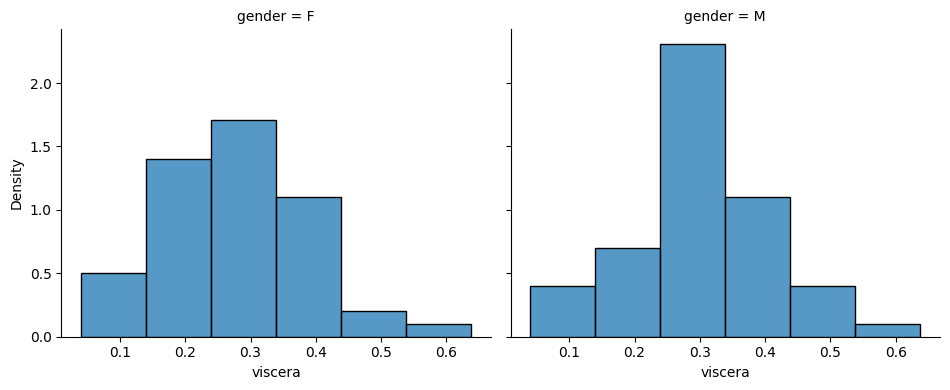

In [5]:
#| fig-align: center
sns.displot(abl, x='viscera', col='gender', kind='hist', stat='density', 
            binwidth=0.1, height=4, aspect=1.2);

:::

A Quantile-Quantile plot is a graphical diagnostic tool for assessing if a
dataset follows a particular distribution. Most of the time we would be
interested in comparing against a Normal distribution.

A QQ-plot plots the standardized sample quantiles against the theoretical
quantiles of a N(0; 1) distribution. If they fall on a straight line, then we
would say that there is evidence that the data came from a normal distribution.
Especially for unimodal datasets, the points in the middle will fall close to
the line. The value of a QQ-plot is in judging if the tails of the data are
fatter or thinner than the tails of the Normal. 


::: {layout-ncol=2}
![Thinner](figs/fig-qq-1-3.png){width=80%}

![Fatter](figs/fig-qq-1-4.png){width=80%}

:::

::: {#exm-abalone-1b style="background-color: #D5D1D164; padding: 20px"}

### Abalone measurements QQ-plots
\index{Abalone!QQ-plots}

If we compare the qq-plots from the data (below) with the reference (above), we
can infer that for females, the left tail is thinner than a Normal - it abruptly
cuts off. For males, both the left and the right tail are fatter than a
Normal's.

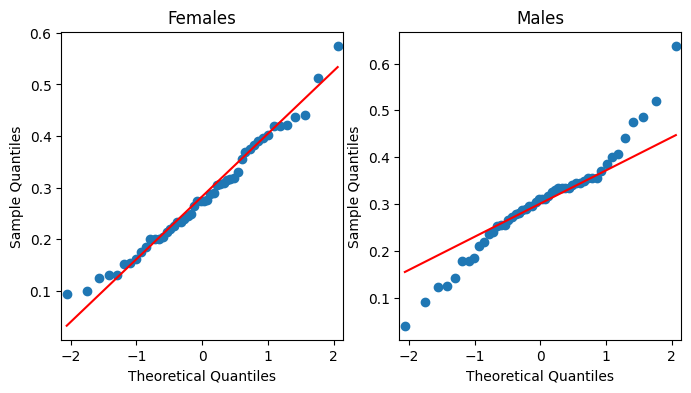

In [6]:
#| fig-align: center
f, axs = plt.subplots(1, 2, figsize=(8,4))
tmp = plt.subplot(121)
sm.qqplot(x, line="q", ax=tmp)
tmp.set_title('Females')
tmp = plt.subplot(122)
sm.qqplot(y, line="q", ax=tmp)
tmp.set_title('Males');

:::
<br>

There are also numerous hypothesis tests for Normality. If you are keen on
learning about them, take a look at the references @sec-02-ref.

We also need to assess if the variances are equal. While there are many
hypothesis tests specifically for assessing if variances are equal (e.g. Levene,
Bartlett), in our class, I advocate a simple rule of thumb. If the larger s.d is
more than twice the smaller one, than we should not use the equal variance form
of the test. This rule of thumb is widely used in practice (see the references
@sec-02-ref).

In [7]:
abl.groupby('gender').describe()

viscera                                                            
         count     mean       std    min       25%    50%       75%    max
gender                                                                    
F         50.0  0.28241  0.108707  0.095  0.201250  0.275  0.365125  0.575
M         50.0  0.30220  0.108746  0.040  0.253125  0.310  0.348750  0.638

We would conclude that there is no significant difference between the mean 
viscera weight of males and females.

## Paired Sample Tests

The data in a paired sample test also arises from two groups, but the two groups 
are not independent. A very common scenario that gives rise to this test is when 
the same subject receives both treatments. His/her measurement under each treatment 
gives rise to a measurement in each group. However, the measurements are no longer 
independent.

::: {#exm-reaction-time style="background-color: #D5D1D164; padding: 20px"}
### Reaction time of drivers
\index{Reaction time}

Consider a study on 32 drivers sampled from a driving school. Each driver is 
put in a simulation of a driving situation, where a target flashes red and  green
at random periods. Whenever the driver sees red, he/she has to press a brake button.

For each driver, the study is carried out twice - at one of the repetitions, the
individual carries on a phone conversation while at the other, the driver
listens to the radio. Each measurement falls under one of two groups - "phone"
or "radio", but the measurements for driver $i$ are clearly related. 

*Some people might just have a slower/faster baseline reaction time!*

This is a situation where a paired sample test is appropriate, not an
independent sample test.

:::

### Formal Set-up

Suppose that we observe $X_1, \ldots , X_n$ independent observations from group
1 and $Y_1, \ldots, Y_n$ independent observations from group 2. However the pair 
$(X_i, Y_i)$ are correlated. Similar to the previous section, it is assumed that

\begin{eqnarray}
X_i &\sim& N(\mu_1,\, \sigma_1^2),\; i=1,\ldots,n \\
Y_j &\sim& N(\mu_2,\, \sigma_2^2),\; j=1,\ldots,n
\end{eqnarray}


We let $D_i = X_i - Y_i$ for $i=1, \ldots, n$. It follows that 
$$
D_i \sim N(\mu_1 - \mu_2,\; \sigma^2_1 + \sigma^2_2 - 2 cov(X_i, Y_i))
$$
The null and alternative hypotheses are stated in terms of the distribution of
$D_i$:

\begin{eqnarray*}
H_0: & \mu_D = 0 \\
H_1: & \mu_D \ne 0
\end{eqnarray*}

The test statistic for this test is:

$$
T_2 = \frac{\bar{D} - 0 }{s / \sqrt{n} }
$$
where 
$$
s^2 = \frac{\sum_{i=1}^n (D_i - \bar{D})^2}{(n - 1)}
$$

Under $H_0$, the test statistic $T_2 \sim t_{n - 1}$. When we use a software
to apply the test above, it will typically also return a confidence interval,
computed as

$$
\bar{D} \pm t_{n - 1, 1 - \alpha/2} \times s / \sqrt{n}
$$

::: {#exm-hr-1 style="background-color: #D5D1D164; padding: 20px"}
### Example: Heart Rate Before/After Treadmill
\index{Treadmill!Paired t-test}

The following dataset comes from a textbook. In a self-recorded experiment, 
an individual recorded his heart rate before using a treadmill (baseline) and 
5 minutes after use, for 12 days in 2006. 

In [8]:
hr_df = pd.read_csv("data/health_promo_hr.csv")
p_test_out = stats.ttest_rel(hr_df.baseline, hr_df.after5)

print(f"""
  The $p$-value for the test is {p_test_out.pvalue:.2g}. 
  The difference in means is {hr_df.baseline.mean() - hr_df.after5.mean():.3f}. 
  """)


  The $p$-value for the test is 2.2e-10. 
  The difference in means is -15.229. 
  


While we do not include them here, it is imperative to also make the checks for
Normality. If you were to make them, you would realise that the sample size is
rather small. It is difficult to make the case for Normality here.

Here is a plot that is particularly useful in paired sample studies:

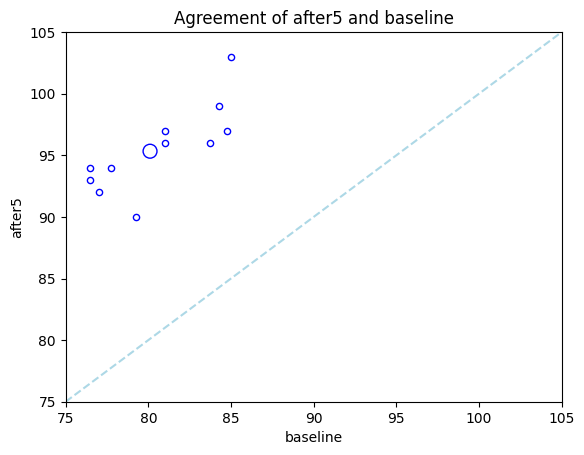

In [9]:
#| fig-align: center
#| fig-cap: "Agreement plot"
ax1 = hr_df.plot(x='baseline', y='after5',kind='scatter', marker='o', 
                 edgecolor='blue', color='none')
group_means = hr_df.loc[:, ['baseline', 'after5']].mean(axis=0)
ax1.set_xlim(75, 105)
ax1.set_ylim(75,105)
ax1.plot([75,105], [75,105], color="lightblue", linestyle="dashed");
ax1.scatter(group_means.iloc[0], group_means.iloc[1],  marker='o', 
            edgecolor='blue', color='none', s=100);
ax1.set_title('Agreement of after5 and baseline');

<br>

In an agreement plot, we check to see if the scatter of points is close to the 
diagonal. If it is, we have evidence of little difference between the means. The
largest circle in the plot corresponds to the mean readings, before and after 
the treadmill run.

:::

## ANoVA

In this section, we introduce the *one-way analysis of variance* (ANOVA), which 
generalises the $t$-test methodology to more than 2 groups. Hypothesis tests in
the ANOVA framework require the assumption of Normality.

While the $F$-test in ANOVA provides a determination of whether or not the group
means are different, in practice, we would always want to follow up with
specific comparisons between groups as well.

::: {#exm-antibiotics-1 style="background-color: #D5D1D164; padding: 20px"}
### Heifers dataset
\index{Heifers!Description}

The following example was taken from 
[Introduction to Statistical Data Analysis for Life Sciences](https://biostatistics.dk/isdals/). 

An experiment with dung from heifers was carried out in order to explore the
influence of antibiotics on the decomposition of dung organic material. As part
of the experiment, 36 heifers were randomly assigned into six groups. Note that
a heifer is a young, female cow that has not had her first calf yet.

Antibiotics of different types were added to the feed for heifers in five of the 
groups. The remaining group served as a control group. For each heifer, a bag of 
dung was dug into the soil, and after 8 weeks the amount of organic material was 
measured for each bag.

Here is a boxplot of the data from each group, along with summary statistics in 
a table below.

In [6]:
tartar = pd.read_excel("data/tartar.xlsx")

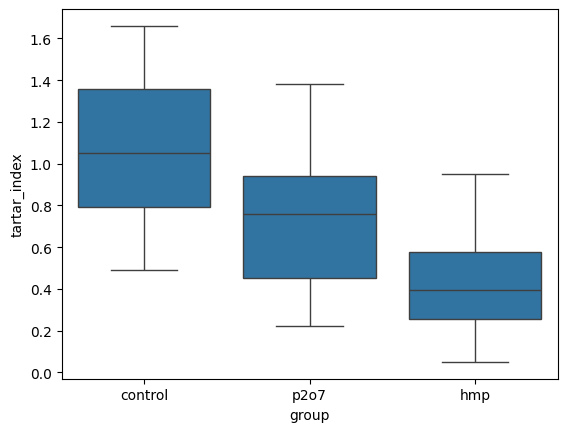

In [10]:
sns.boxplot(tartar, x='group', y='tartar_index');

In [18]:
tartar_lm = ols("tartar_index ~ C(group, Treatment('control'))", data=tartar).fit()
anova_tab = sm.stats.anova_lm(tartar_lm, type=3,)
anova_tab

,df,sum_sq,mean_sq,F,PR(>F)
"C(group, Treatment('control'))",2.0,1.804561,0.902281,6.668443,0.005198
Residual,23.0,3.112039,0.135306,NaN,NaN


In [19]:
tartar_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           tartar_index   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     6.668
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00520
Time:                        17:12:02   Log-Likelihood:                -9.2958
No. Observations:                  26   AIC:                             24.59
Df Residuals:                      23   BIC:                             28.37
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  1.0889      0.123      8.881      0.000       0.835       1.343
C(group, Treatment('control'))[T.hmp]     -0.6514      0.179     -3.644      0.001      -1.021      -0.282
C(group, Treatment('control'))[T.p2o7]    -0.3422      0.173     -1.974      0.061      -0.701       0.016
==============================================================================
Omnibus:                        1.471   Durbin-Watson:                   1.737
Prob(Omnibus):                  0.479   Jarque-Bera (JB):                0.957
Skew:                           0.054   Prob(JB):                        0.620
Kurtosis:                       2.066   Cond. No.                         3.68
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

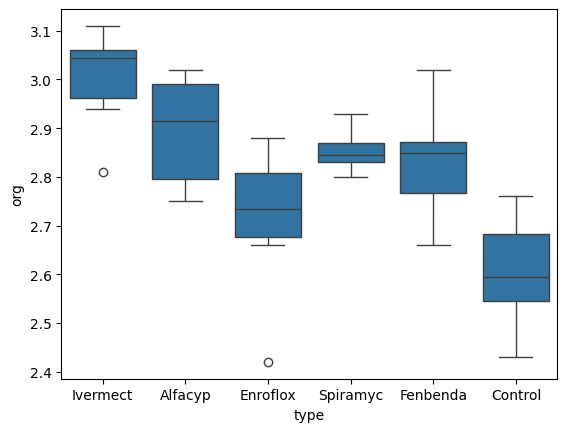

In [10]:
#| fig-align: center
heifers = pd.read_csv('data/antibio.csv')
sns.boxplot(heifers, x='type', y='org',);

Compared to the control group, it does appear that the median organic weight of
the dung from the other heifer groups is higher. The following table 
displays the mean, standard deviation, and count from each group:

In [11]:
heifers.groupby('type').describe()

org                                                       
         count      mean       std   min     25%    50%     75%   max
type                                                                 
Alfacyp    6.0  2.895000  0.116748  2.75  2.7950  2.915  2.9900  3.02
Control    6.0  2.603333  0.118771  2.43  2.5450  2.595  2.6825  2.76
Enroflox   6.0  2.710000  0.161988  2.42  2.6775  2.735  2.8075  2.88
Fenbenda   6.0  2.833333  0.123558  2.66  2.7675  2.850  2.8725  3.02
Ivermect   6.0  3.001667  0.109438  2.81  2.9625  3.045  3.0600  3.11
Spiramyc   4.0  2.855000  0.054467  2.80  2.8300  2.845  2.8700  2.93

Observe that the Spiramycin group only yielded 4 readings instead of 6. Our goal
in this topic is to understand a technique for assessing if group means are
statistically different from one another. Here are the specific analyses that we 
shall carry out:

#### Heifers: Questions of Interest

1. Is there any significant difference, at 5% level, between the mean decomposition
   level of the groups?
2. At 5% level, is the mean level for Enrofloxacin different from the control group?
3. Pharmacologically speaking, Ivermectin and Fenbendazole are similar to each
   other. Let us call this sub-group (A). They work differently than Enrofloxacin.
   At 5% level, is there a significant difference between the mean from sub-group 
   A and Enrofloxacin?

:::

### Formal Set-up

Suppose there are $k$ groups with $n_i$ observations in the $i$-th group. The 
$j$-th observation in the $i$-th group will be denoted by $Y_{ij}$. In the One-Way
ANOVA, we assume the following model:

\begin{equation}
Y_{ij}  = \mu + \alpha_i + e_{ij},\; i=1,\ldots,k,\; j=1,\ldots,n_i
\end{equation}

* $\mu$ is a constant, representing the underlying mean of all groups taken together.
* $\alpha_i$ is a constant specific to the $i$-th group. It represents the difference 
  between the mean of the $i$-th group and the overall mean.
* $e_{ij}$ represents random error about the mean $\mu + \alpha_i$ for an individual 
  observation from the $i$-th group.

In terms of distributions, we assume that the $e_{ij}$ are i.i.d from a Normal 
distribution with mean 0 and variance $\sigma^2$. This leads to the model for 
each observation:

$$
Y_{ij} \sim N(\mu + \alpha_i,\; \sigma^2)
$$

It is not possible to estimate both $\mu$ and all the $k$ different $\alpha_i$'s, 
since we only have $k$ observed mean values for the $k$ groups. For identifiability 
purposes, we need to constrain the parameters. There are two common constraints used,
and note that different software have different defaults:

1. Setting $\sum_{i=1}^k \alpha_i = 0$, or
2. Setting $\alpha_1= 0$.

Continuing on from the equation for $Y_{ij}$, let us denote the mean for the $i$-th group as 
$\overline{Y_i}$, and the overall mean of all observations as 
$\overline{\overline{Y}}$. We can then write the deviation of an individual 
observation from the overall mean as:

$$
Y_{ij} - \overline{\overline{Y}} = \underbrace{(Y_{ij} - \overline{Y_i})}_{\text{within}} + 
\underbrace{(\overline{Y_i} - \overline{\overline{Y}})}_{\text{between}}
$$

The first term on the right of the above equation is an indication of 
*within-group variability*. The second term on the right is an indication of 
*between-group variability*. The intuition behind the ANOVA procedure is that 
if the between-group variability is large and the within-group variability is 
small, then we have evidence that the group means are different.

If we square both sides of the above equation and sum over all observations, we arrive 
at the following equation; the essence of ANOVA:

$$
\sum_{i=1}^k \sum_{j=1}^{n_i} \left( Y_{ij} - \overline{\overline{Y}} \right)^2 =
\sum_{i=1}^k \sum_{j=1}^{n_i} \left( Y_{ij} - \overline{Y_i} \right)^2 + 
\sum_{i=1}^k \sum_{j=1}^{n_i} \left( \overline{Y_i} - 
                                     \overline{\overline{Y}} \right)^2 
$$

The squared sums above are referred to as:
$$
SS_T = SS_W + SS_B
$$

* $SS_T$: Sum of Squares Total,
* $SS_W$: Sum of Squares Within, and
* $SS_B$: Sum of Squares Between.

In addition the following definitions are important for understanding the ANOVA 
output:

1. The Between Mean Square:
$$
MS_B = \frac{SS_B}{k-1}
$$
2. The Within Mean Square:
$$
MS_W = \frac{SS_W}{n - k}
$$

The mean squares are estimates of the variability between and within groups. The 
ratio of these quantities is the test statistic.

### $F$-Test in One-Way ANOVA

The null and alternative hypotheses are:

\begin{eqnarray*}
H_0 &:& \alpha_i = 0 \text{ for all } i \\
H_1 &:& \alpha_i \ne 0 \text{ for at least one } i
\end{eqnarray*}

The test statistic is given by 
$$
F = \frac{MS_B}{MS_W}
$$

Under $H_0$, the statistic $F$ follows an $F$ distribution with $k-1$ and $n-k$
degrees of freedom.

### Assumptions

These are the assumptions that will need to be validated.

1. The observations are independent of each other. This is usually a characteristic 
   of the design of the experiment, and is not something we can always check from
   the data.
2. The errors are Normally distributed. Residuals can be calculated as follows:
$$
Y_{ij} - \overline{Y_i}
$$
   The distribution of these residuals should be checked for Normality.
3. The variance within each group is the same. In ANOVA, the $MS_W$ is a pooled 
   estimate (across the groups) that is used; in order for this to be valid,
   the variance within each group should be identical. As in the 2-sample situation,
   we shall avoid separate hypotheses tests and proceed with the rule-of-thumb
   that if the ratio of the largest to smallest standard deviation is less than
   2, we can proceed with the analysis.

   
::: {#exm-antibiotics-2 style="background-color: #D5D1D164; padding: 20px"}
### Heifers ANOVA F-test
\index{Heifers!F-test}

Let us now apply the F-test to the heifers dataset.

In [12]:
heifer_lm = ols('org ~ type', data=heifers).fit()
anova_tab = sm.stats.anova_lm(heifer_lm, type=3,)
anova_tab

,df,sum_sq,mean_sq,F,PR(>F)
type,5.0,0.590824,0.118165,7.972558,0.00009
Residual,28.0,0.415000,0.014821,NaN,NaN


At the 5% significance level, we reject the null hypothesis to conclude that the
group means are significantly different from one another. This answers the first question we set out to.

To extract the estimated parameters, we can use the following code:

In [13]:
heifer_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    org   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     7.973
Date:                Fri, 22 May 2026   Prob (F-statistic):           8.95e-05
Time:                        20:47:42   Log-Likelihood:                 26.655
No. Observations:                  34   AIC:                            -41.31
Df Residuals:                      28   BIC:                            -32.15
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.8950      0.050     58.248      0.000       2.793       2.997
type[T.Control]     -0.2917      0.070     -4.150      0.000      -0.436      -0.148
type[T.Enroflox]    -0.1850      0.070     -2.632      0.014      -0.329      -0.041
type[T.Fenbenda]    -0.0617      0.070     -0.877      0.388      -0.206       0.082
type[T.Ivermect]     0.1067      0.070      1.518      0.140      -0.037       0.251
type[T.Spiramyc]    -0.0400      0.079     -0.509      0.615      -0.201       0.121
==============================================================================
Omnibus:                        2.172   Durbin-Watson:                   2.146
Prob(Omnibus):                  0.338   Jarque-Bera (JB):                1.704
Skew:                          -0.545   Prob(JB):                        0.427
Kurtosis:                       2.876   Cond. No.                         6.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<br/>

When estimating, Python sets one of the $\alpha_i$ to be equal to 0. 
We can tell from the output that the constraint has been placed on the coefficient for `Alfacyp` (since it is missing).

From the output, we can read off (the Intercept term) that the estimate for 
`Alfacyp` is precisely
$$
2.895 + 0 = 2.895
$$

To check the assumptions, we can use the following code:

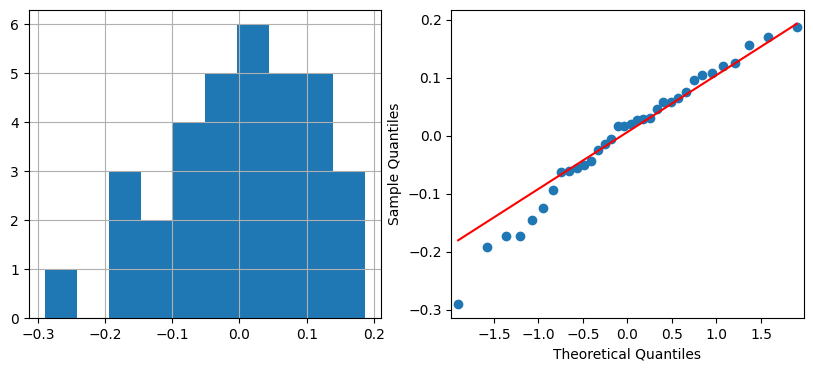

In [14]:
#| fig-align: center
f, axs = plt.subplots(1, 2, figsize=(10,4))
tmp = plt.subplot(121)
heifer_lm.resid.hist();
tmp = plt.subplot(122)
sm.qqplot(heifer_lm.resid, line="q", ax=tmp);

:::

### Comparing specific groups {#sec-spec-grps}

The $F$-test in a One-Way ANOVA indicates if all means are equal, but does not
provide further insight into which particular groups differ. If we had specified
beforehand that we wished to test if two particular groups $i_1$ and $i_2$ had
different means, we could do so with a t-test. Here are the details to compute a
confidence interval in this case:

1. Compute the estimate of the difference between the two means:
$$
\overline{Y_{i_1}} - \overline{Y_{i_2}}
$$
2. Compute the standard error of the above estimator:
$$
\sqrt{MS_W \left( \frac{1}{n_{i_1}} + \frac{1}{n_{i_2}} \right) }
$$
3. Compute the $100(1- \alpha)%$ confidence interval as:
$$
\overline{Y_{i_1}} - \overline{Y_{i_2}} \pm 
t_{n-k, \alpha/2}  \times
\sqrt{MS_W \left( \frac{1}{n_{i_1}} + \frac{1}{n_{i_2}} \right) }
$$

::: {.callout-note}

<p>
If you notice from the summary statistics output for each group, the
rule-of-thumb regarding standard deviations has not been satisfied. The ratio of
largest to smallest standard deviations is slightly more than 2. Hence *we
should not continue with ANOVA*; the pooled estimate of the variance may not be
valid.
</p>

<p>
However, we shall proceed with this dataset just to demonstrate the next few
techniques, instead of introducing a new dataset.
</p>
:::

::: {#exm-antibiotics-3 style="background-color: #D5D1D164; padding: 20px"}

### Enrofloxacin vs. Control
\index{Heifers!Comparing two groups}

Let us attempt to answer question (2), that we had set out earlier.

In [15]:
est1  = heifer_lm.params.iloc[2] - heifer_lm.params.iloc[1]
MSW = heifer_lm.mse_resid
df = heifer_lm.df_resid
q1 = -stats.t.ppf(0.025, df)

lower_ci = est1 - q1*np.sqrt(MSW * (1/6 + 1/4))
upper_ci = est1 + q1*np.sqrt(MSW * (1/6 + 1/4))
print("The 95% CI for the diff. between Enrofloxacin and control is" +
      f"({lower_ci:.3f}, {upper_ci:.3f}).") 

The 95% CI for the diff. between Enrofloxacin and control is(-0.054, 0.268).


As the confidence interval contains the value 0, the binary conclusion would be 
to not reject the null hypothesis at the 5% level.

:::

### Contrast Estimation

A more general comparison, such as the comparison of a collection of $l_1$ groups
with another collection of $l_2$ groups, is also possible. First, note that a linear 
contrast is any linear combination of the individual group means such that the 
linear coefficients add up to 0. In other words, consider $L$ such that 

$$
L = \sum_{i=1}^k c_i \overline{Y_i}, \text{ where } \sum_{i=1}^k c_i = 0
$$

Note that the comparison of two groups in @sec-spec-grps is a special case of this
linear contrast. 

Here is the procedure for computing confidence intervals for a linear contrast:

1. Compute the estimate of the contrast:
$$
L = \sum_{i=1}^k c_i \overline{Y_i}
$$
2. Compute the standard error of the above estimator:
$$
\sqrt{MS_W \sum_{i=1}^k \frac{c_i^2}{n_i} }
$$
3. Compute the $100(1- \alpha)%$ confidence interval as:
$$
L \pm
t_{n-k, \alpha/2}  \times
\sqrt{MS_W \sum_{i=1}^k \frac{c_i^2}{n_i} }
$$

::: {#exm-antibiotics-4 style="background-color: #D5D1D164; padding: 20px"}

### Heifers: Comparing collections of groups
\index{Heifers!Contrast estimation}

As we mentioned earliers, let sub-group 1 consist of Ivermectin and Fenbendazole. 
Here is how we can compute a confidence interval for the difference between 
this sub-group, and Enrofloxacin.

In [16]:
c1 = np.array([-1, 0.5, 0.5])
n_vals = np.array([6, 6, 6,])
L = np.sum(c1 * heifer_lm.params.iloc[2:5])

MSW = heifer_lm.mse_resid
df = heifer_lm.df_resid
q1 = -stats.t.ppf(0.025, df)
se1 = np.sqrt(MSW*np.sum(c1**2 / n_vals))

lower_ci = L - q1*se1
upper_ci = L + q1*se1
print("The 95% CI for the diff. between the two groups is " +
      f"({lower_ci:.3f}, {upper_ci:.3f}).") 

The 95% CI for the diff. between the two groups is (0.083, 0.332).


:::

### Multiple Comparisons

The procedures in the previous two subsections correspond to contrasts that we 
had specified before collecting or studying the data. If, instead, we wished 
to perform particular comparisons after studying the group means, or if we wish 
to compute all pairwise contrasts, then we need to adjust for the fact that we are 
conducting multiple tests. If we do not do so, the chance of making at least one 
false positive increases greatly.

#### Bonferroni

The simplest method for correcting for multiple comparisons is to use the Bonferroni 
correction. Suppose we wish to perform $m$ pairwise comparisons, either as a test or 
by computing confidence intervals. If we wish to maintain the significance level
of each test at $\alpha$, then we should perform each of the $m$ tests/confidence 
intervals at $\alpha/m$.

#### TukeyHSD

This procedure is known as Tukey's Honestly Significant Difference. It is designed 
to construct confidence intervals for **all** pairwise comparisons. For the same 
$\alpha$-level, Tukey's HSD method provides shorter confidence intervals than
a Bonferroni correction for all pairwise comparisons.

::: {#exm-antibiotics-5 style="background-color: #D5D1D164; padding: 20px"}

### Multiple comparisons
\index{Heifers!Multiple comparisons}

Let us apply Tukey's procedure to the heifers dataset.

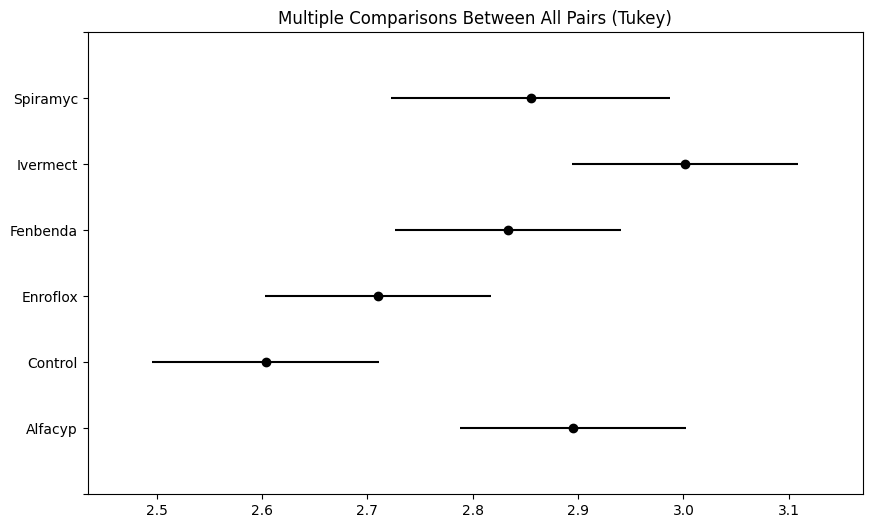

In [17]:
#| fig-align: center
cp = mc.MultiComparison(heifers.org, heifers.type)
tk = cp.tukeyhsd()
#print(tk)

tk.plot_simultaneous();

:::

## Categorical Variables

There are two sub-types of categorical variables:

* A categorical variable is *ordinal* if the observations can be ordered, but do not
have specific quantitative values.
* A categorical variable is *nominal* if the observations can be classified into
categories, but the categories have no specific ordering.

In this topic, we shall discuss techniques for identifying the presence, and for 
measuring the strength, of the association between two categorical variables. 

::: {#exm-chest-pain-1 style="background-color: #D5D1D164; padding: 20px"}

### Chest pain and gender
\index{Chest pain!Description}

Suppose that 1073 NUH patients who were at high risk for cardiovascular disease
(CVD) were randomly sampled. They were then queried on two things:

1. Had they experienced the onset of severe chest pain in the preceding 6
months? (yes/no)
2. What was their gender? (male/female)

The data would probably be summarised and presented in this format, which is 
known as a *contingency table*.

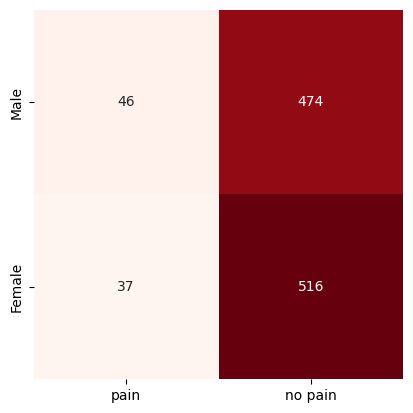

In [18]:
#| fig-align: center
#| 
chest_array = np.array([[46, 474], [37, 516]])
#print(chest_array)

sns.heatmap(chest_array, annot=True, square=True, fmt='', 
            xticklabels=['pain', 'no pain'],
            yticklabels=['Male', 'Female'], 
            cmap='Reds', cbar=False, );

In the above table, the rows correspond to gender (Male, followed by Female) and
the columns correspond to chest pain (from left to right: presence, then
absence). Hence 516 of the 1073 patients were females who did not experience
chest pain.

In a contingency table, each observation from the dataset falls in exactly one
of the cells. The sum of all entries in the cells equals the number of
independent observations in the dataset. All the techniques we shall touch upon
in this chapter are applicable to contingency tables.

:::

### $\chi^2$-Test for Independence 

In the contingency table above, the two categorical variables are *Gender* and
*Presence/absence of Pain*. With contingency tables, the main inferential task
usually relates to assessing the association between the two categorical
variables.

::: {.callout-note}

If two categorical variables are **independent**, then the joint distribution of
the variables would be equal to the product of the marginals. If two variables
are not independent, we say that they are **associated**.

:::

The $\chi^2$-test uses the definition above to assess if two variables in a 
contingency table are associated. The null and alternative hypotheses are 

\begin{eqnarray*}
H_0 &:& \text{The two variables are indepdendent.}  \\
H_1 &:& \text{The two variables are not indepdendent.}
\end{eqnarray*}

Under the null hypothesis, we can estimate the joint distribution from the
observed marginal counts. Based on this estimated joint distribution, we then 
compute *expected* counts (which may not be integers) for each cell. The test
statistic essentially compares the deviation of *observed* cell counts from the 
expected cell counts. 

::: {#exm-chest-pain-2 style="background-color: #D5D1D164; padding: 20px"}

### Chest pain and gender expected counts
\index{Chest pain!Expected counts}

Continuing from the chest pain example, we can compute the estimated marginals using 
row and column proportions

In [19]:
col_prop,row_prop = sm.stats.Table(chest_array).marginal_probabilities

print(f"""
  The proportion of males in the sample was {col_prop[0]:.3f}.
  The proportion of all patients who experienced chest pain was {row_prop[0]:.3f}.
  """)


  The proportion of males in the sample was 0.485.
  The proportion of all patients who experienced chest pain was 0.077.
  


If we let $X$ represent gender and $Y$ represent chest pain, then we can estimate that:

\begin{eqnarray*}
\widehat{P}(X = \text{male}) &=& 0.485  \\
\widehat{P}(Y = \text{pain}) &=& 0.077
\end{eqnarray*}

Consequently, *under $H_0$* (independence), we would estimate
$$
\widehat{P}(X = \text{male},\, Y= \text{pain}) = 0.485 \times 0.077 \approx 0.04
$$

From a sample of size 1073, the expected count for this cell is then 

$$
0.04 \times 1073 = 42.92
$$

:::

Using the approach above, we can derive a general formula for the expected count
in each cell:
$$
\text{Expected count} = \frac{\text{Row total} \times \text{Column total}}{\text{Total sample size}}
$$

The formula for the $\chi^2$-test statistic (with continuity correction) is:
$$
\chi^2 = \sum \frac{|\text{expected} - \text{observed} |^2}{\text{expected count}} 
$$

The sum is taken over every cell in the table. Hence in a $2\times2$ table, as we have here, there would be 4 terms in the summation. 

::: {#exm-chest-pain-3 style="background-color: #D5D1D164; padding: 20px"}
### Chest pain and gender $\chi^2$ test
\index{Chest pain!Chi-squared test}

Let us see how we can apply and interpret the $\chi^2$-test for the data in the chest pain example.

In [20]:
chisq_output = stats.chi2_contingency(chest_array, correction=False)

print(f"""
  The p-value is {chisq_output.pvalue:.3f}.
  The test-statistic value is {chisq_output.statistic:.3f}.""")


  The p-value is 0.187.
  The test-statistic value is 1.744.


Since the $p$-value is 0.1817, we would not reject the null hypothesis at significance 
level 5%. We do not have sufficient evidence to conclude that the variables are not 
independent.

To extract the expected cell counts, we can use the following code: 

In [21]:
chisq_output.expected_freq

array([[ 40.22367195, 479.77632805],
       [ 42.77632805, 510.22367195]])

The test statistic in the $\chi^2$-test compares the above table to the *observed* table.

:::

::: {.callout-note}

It is only suitable to use the $\chi^2$-test when all *expected cell counts* are
larger than 5. If this condition fails, one recommendation is to use a
continuity correction, which modifies the test statistic to be

$$
\chi^2 = \sum \frac{(|\text{expected} - \text{observed}| - 0.5)^2}{\text{expected count}} 
$$

However, I advocate using [Fisher's exact test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fisher_exact.html),
which is also a test of independence, but measures deviations under slightly
different assumptions. The test uses the exact distribution of the test
statistic (not an approximation) so it will apply to small datasets as well.

:::

::: {#exm-chest-pain-4 style="background-color: #D5D1D164; padding: 20px"}
### Chest pain and gender Fisher Exact test
\index{Chest pain!Fisher test}

Here is how we can apply Fisher's exact test to the same dataset.

In [ ]:
stats.fisher_exact(chest_array)

As we can see from the p-value, the result is similar to the $\chi^2$-test.

:::

### Measures of Association

Measures of association quantify how two random variables vary together. When
both variables are continuous, a common measure that is used is Pearson
correlation. We shall return to this in topics such as regression. For now, we
touch on bivariate measures of association for contingency tables (two
categorical variables).

### Odds Ratio

The most generally applicable measure of association, for 2x2 tables with
nominal variables, is the Odds Ratio (OR). Suppose we have $X$ and $Y$ to be Bernoulli 
random variables with (population) success probabilities $p_1$ and $p_2$. 

We define the odds of success for $X$ to be 
$$
\frac{p_1}{1-p_1}
$$
Similarly, the odds of success for random variable $Y$ is $\frac{p_2}{1-p_2}$. 

In order to measure the strength of their association, we use the *odds ratio*:
$$
\frac{p_1/ (1-p_1)}{p_2/(1-p_2)}
$$

The odds ratio can take on any value from 0 to $\infty$.

* A value of 1 indicates no association between $X$ and $Y$. If $X$ and $Y$ were 
  independent, this is what we would observe.
* Deviations from 1 indicate stronger association between the variables.
* Note that deviations from 1 are not symmetric. For a given pair of variables,
  an association of 0.25 or 4 is the same - it is just a matter of which variable
  we put in the numerator odds.
  
Due to the above asymmetry, we often use the log-odds-ratio instead:
$$
\log \frac{p_1/ (1-p_1)}{p_2/(1-p_2)} 
$$

* Log-odds-ratios can take values from $-\infty$ to $\infty$.
* A value of 0 indicates no association between $X$ and $Y$.
* Deviations from 0 indicate stronger association between the variables, and deviations 
  are now symmetric; a log-odds-ratio of -0.2 indicates the same *strength* as 0.2, just 
  the opposite direction.
  
To obtain a confidence interval for the odds-ratio, we work with the log-odds ratio and 
then exponentiate the resulting interval. Here are the steps:

1. The sample data in a 2x2 table can be labelled as $n_{11}, n_{12}, n_{21}, n_{22}$.
2. The *sample* odds ratio is 
$$
\widehat{OR} = \frac{n_{11} \times n_{22}}{n_{12} \times n_{21}}
$$
3. For a large sample size, it can be shown that $\log \widehat{OR}$ follows a Normal 
   distribution. Hence a 95% confidence interval can be obtained through
$$
\log \frac{n_{11} \times n_{22}}{n_{12} \times n_{21}} \pm z_{0.025} 
\times ASE(\log \widehat{OR})
$$

where 

* the ASE (Asymptotic Standard Error) of the estimator is 
$$
\sqrt{\frac{1}{n_{11}} + \frac{1}{n_{12}} + \frac{1}{n_{21}} + \frac{1}{n_{22}}} 
$$

::: {#exm-chest-pain-4 style="background-color: #D5D1D164; padding: 20px"}
### Chest pain and gender odds ratio
\index{Chest pain!Odds ratio}

Let us compute the confidence interval for the odds ratio in the chest pain and
gender example from earlier.

In [22]:
chest_tab2 = sm.stats.Table2x2(chest_array)

chest_tab2.summary()

,Estimate,SE,LCB,UCB,p-value
Odds ratio,1.353,,0.863,2.123,0.188
Log odds ratio,0.303,0.230,-0.148,0.753,0.188
Risk ratio,1.322,,0.872,2.004,0.188
Log risk ratio,0.279,0.212,-0.137,0.695,0.188


:::

### For Ordinal Variables

When both variables are ordinal, it is often useful to compute the strength 
(or lack) of any monotone trend association. It allows us to assess if

> As the level of $X$ increases, responses on $Y$ tend to increase toward 
> higher levels, or responses on $Y$ tend to decrease towards lower levels.

For instance, perhaps job satisfaction tends to increase as income does. In this
section, we shall discuss a measure for ordinal variables, analogous to
Pearson's correlation for quantitative variables, that describes the degree to 
which the relationship is monotone. It is based on the idea of a concordant or
discordant pair of subjects.

* A **pair of subjects** is *concordant* if the subject ranked higher on $X$ also 
  ranks higher on $Y$. 
* A **pair** is *discordant* if the subject ranking higher on $X$ ranks lower on $Y$.
* A **pair** is *tied* if the subjects have the same classification on $X$ and/or $Y$.

If we let 

* $C$: number of concordant pairs in a dataset, and
* $D$: number of discordant pairs in a dataset.

Then if $C$ is much larger than $D$, we would have reason to believe that there 
is a strong positive association between the two variables. Here are two measures
of association based on $C$ and $D$:

1. Goodman-Kruskal $\gamma$ is computed as 
$$
\gamma = \frac{C - D}{C + D}
$$
2. Kendall $\tau_b$ is 
$$
\tau_b = \frac{C - D}{A}
$$
   where $A$ is a normalising constant that results in a measure that works better with ties,
   and is less sensitive than $\gamma$ to the cut-points defining the categories. 
   $\gamma$ has the advantage that it is more easily interpretable.

For both measures, values close to 0 indicate a very weak trend, while values 
close to 1 (or -1) indicate a strong positive (negative) association.

::: {#exm-job-income-1 style="background-color: #D5D1D164; padding: 20px"}

### Job satisfaction by income
\index{Job satisfaction!Ordinal association}

Consider the following table, obtained from @agresti2012categorical. The
original data come from a nationwide survey conducted in the US in 1996.

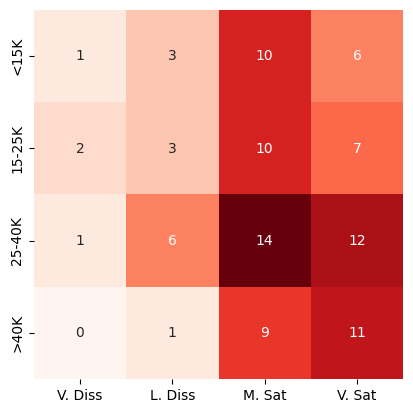

In [23]:
#| fig-align: center
us_svy_tab = np.array([[1, 3, 10, 6], 
                      [2, 3, 10, 7],
                      [1, 6, 14, 12],
                      [0, 1,  9, 11]])
col_names = ['V. Diss', 'L. Diss', 'M. Sat', 'V. Sat']
row_names = ['<15K', '15-25K', '25-40K', '>40K']
sns.heatmap(us_svy_tab, annot=True, square=True, fmt='', 
            xticklabels=col_names,
            yticklabels=row_names, 
            cmap='Reds', cbar=False, );

In measuring the association between these two variables (job satisfaction and income), we are interested in answering questions such as:

> If individual A has higher income than individual B, is individual A more likely to be satisfied in his/her job?

$\gamma$ and $\tau_b$ are measures that quantify this association. For the function in `scipy.stats` that computes this association, we need the data in "long format". Hence we unroll it manually before summoning the method.

In [24]:
dim1 = us_svy_tab.shape
x = []; y=[]
for i in range(0, dim1[0]):
    for j in range(0, dim1[1]):
        for k in range(0, us_svy_tab[i,j]):
            x.append(i)
            y.append(j)

In [25]:
stats.kendalltau(x, y, variant='b')

SignificanceResult(statistic=np.float64(0.15235215134659688), pvalue=np.float64(0.0860294855671433))

The output shows that $\tau_b =0.15$ is positive, and is borderline significant
at 5% level. We can conclude that there is a weak association between job
satisfaction and income.

:::

## Summary 

In this topic, the primary take-aways are the notions of hypothesis tests (HT)
and confidence intervals (CI). Both of these approaches aim to uncover
information about a population using a sample. I strongly advocate the choice of
CI over HT, as the latter option only provides a binary decision. CIs, on the
other hand, provide a range of values to provide a better understanding of the
situation.

Using a small set of applications, we have demonstrated these techniques. We
covered a common scenario where a researcher may need to compare the means
between several groups. We then moved onto another common situation, where one
might be faced with a contingency table. A common query is: What should we do if
the assumptions of the test are not fulfilled? In those circumstances, one
possibility is to turn to nonparametric versions of the test. For instance, the
Kruskal-Wallis test is a HT for comparing the means of several groups whose
distributions are not Normal.

In the section on categorical data, we introduced measures of association for
categorical variables - odds ratio, and Kendall $\tau$. When we have contingency
tables, a common choice has been to display barcharts, or heat maps and use
those to make decisions on. However, I encourage you to use the measures of
association instead. They are intuitive to understand, and can allow you to
compare sub-groups or variation of association over time.

With HT and with CI, there has been a tendency to manipulate the data or tests
until the desired outcome has been reached. Do be watchful of this. Conducting
multiple tests increases the false positive error rate, so please do avoid this
as well. If you conduct multiple tests, adjust for multiple testing. Use
statitsical inference techniques as a guide together with common sense and
domain expertise.

## References {#sec-02-ref}

### Website References

1. Inference recap from Penn State:
   * [Hypothesis testing recap](https://online.stat.psu.edu/statprogram/reviews/statistical-concepts/hypothesis-testing) 
   * [Confidence intervals recap](https://online.stat.psu.edu/statprogram/reviews/statistical-concepts/confidence-intervals)
2. [Tests for Normality](https://online.stat.psu.edu/stat501/lesson/7/7.5) More information on the Kolmogorov-Smirnov and Shapiro-Wilks Tests for Normality.
3. [Overview of $t$-tests](https://www.bmj.com/about-bmj/resources-readers/publications/statistics-square-one/7-t-tests) This page includes the rule of thumb about deciding when
   to use the equal variance test, and when to use the unequal variances version.

### Documentation links

1. [statsmodels ANOVA](https://www.statsmodels.org/stable/examples/notebooks/generated/interactions_anova.html) A more complete example on the application of ANOVA. Return to this when we
   complete the topic on regression.  
2. [Useful functions from scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html): Under the "Hypothesis Tests" section of this page, you can find:
   * Kruskal Wallis - the nonparametric equivalent of ANOVA
   * Wilcoxon signed rank - the nonparametric equivalent of paired sample t-test
   * Mann Whitney test - the nonparametric equivalent of independent samples t test
   * Somer's D - measure of association for two categorical variables (one ordinal and one nominal).